In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
# 1. Data Loading and Preprocessing
try:
    orders_df = pd.read_excel('Superstore_Data.xlsx', sheet_name='Orders')
except:
    orders_df = pd.read_csv('Superstore_Data.xlsx - Orders.csv')

def clean_date(value):
    if pd.isna(value): return None
    if isinstance(value, (pd.Timestamp, datetime.datetime)): return value
    try:
        return datetime.datetime(1899, 12, 30) + datetime.timedelta(days=float(value))
    except:
        return pd.to_datetime(value, errors='coerce')
orders_df['Order Date'] = orders_df['Order Date'].apply(clean_date)

In [3]:
# 2. Define a Generic Prediction Function
def forecast_new_product_sales(df, reference_sub_category, forecast_months=12):
    """
    input: 
        df: dataframe of order
        reference_sub_category: Existing subcategories for benchmarking
        forecast_months: Forecasting the coming months (default 12)
    output:
        history: Historical Monthly Sales Data
        forecast: Forecast monthly sales data
    """
    # 1. Filter and aggregate data
    subset = df[df['Sub-Category'] == reference_sub_category].copy()
    subset.set_index('Order Date', inplace=True)
    
    # Monthly sampling summation (MS = Month Start)
    monthly_sales = subset['Sales'].resample('MS').sum()
    
    # 2. Fill in the missing months
    full_idx = pd.date_range(start=monthly_sales.index.min(), end=monthly_sales.index.max(), freq='MS')
    monthly_sales = monthly_sales.reindex(full_idx, fill_value=0)
    
    # 3. Train the Holt-Winters model (with trend and seasonal components)
    # Employ an 'additive' trend and seasonal components, as sales fluctuations exhibit relatively stable amplitude
    try:
        model = ExponentialSmoothing(
            monthly_sales, 
            seasonal_periods=12, 
            trend='add', 
            seasonal='add', 
            damped_trend=True
        ).fit()
    except:
        # If the data is insufficient to establish a seasonal model, it will revert to a simple trend model.
        print(f"{reference_sub_category}: The data is insufficient for seasonal analysis; a simple trend forecast shall be employed instead.")
        model = ExponentialSmoothing(monthly_sales, trend='add').fit()
        
    # 4. Generate predictions
    forecast = model.forecast(forecast_months)
    
    return monthly_sales, forecast

In [4]:
# 3. User Interaction Area: Enter the new product category you wish to predict
print(f"Available benchmark categories: {orders_df['Sub-Category'].unique()}")

target_product = 'Chairs' 

print(f"\nGenerating... '{target_product}'")
history, forecast = forecast_new_product_sales(orders_df, target_product)

Available benchmark categories: ['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']

Generating... 'Chairs'


D:\anaconda\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


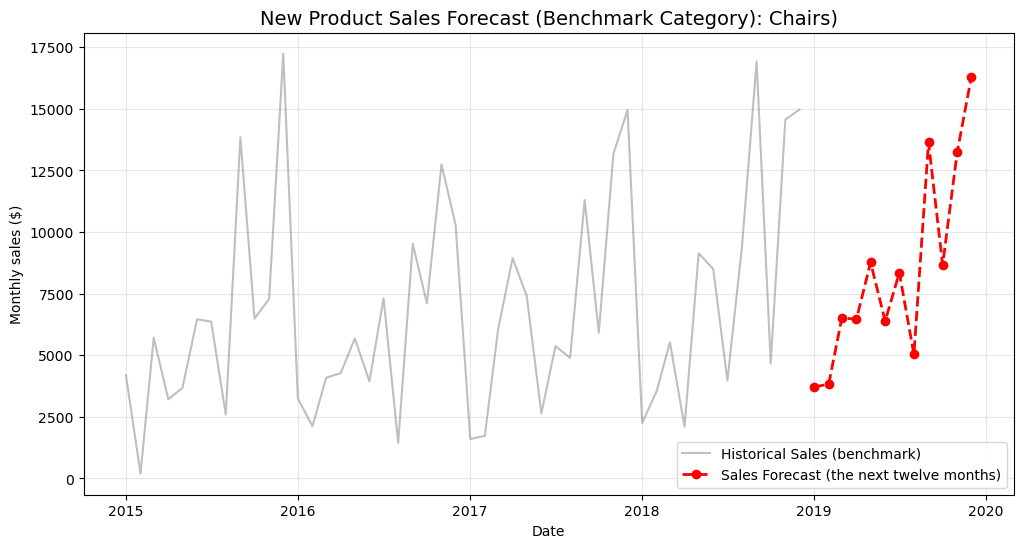


--- Chairs Detailed Forecast for the Next 12 Months ---
   Forecast month  Forecasted sales
0      2019-01-01       3712.053843
1      2019-02-01       3825.390355
2      2019-03-01       6510.801178
3      2019-04-01       6463.616757
4      2019-05-01       8763.240952
5      2019-06-01       6384.377541
6      2019-07-01       8350.489971
7      2019-08-01       5028.849801
8      2019-09-01      13637.968035
9      2019-10-01       8671.437186
10     2019-11-01      13247.831044
11     2019-12-01      16300.996190


In [5]:
# 4. Visualisation and Output of Results
plt.figure(figsize=(12, 6))


plt.plot(history.index, history, label='Historical Sales (benchmark)', color='gray', alpha=0.5)
plt.plot(forecast.index, forecast, label='Sales Forecast (the next twelve months)', color='red', linestyle='--', marker='o', linewidth=2)

plt.title(f'New Product Sales Forecast (Benchmark Category): {target_product})', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Monthly sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print specific values
forecast_df = pd.DataFrame({'Forecast month': forecast.index, 'Forecasted sales': forecast.values})
print(f"\n--- {target_product} Detailed Forecast for the Next 12 Months ---")
print(forecast_df)